In [12]:
from langgraph.graph import END,START,StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from typing import TypedDict,Annotated
from pydantic import BaseModel
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
from langgraph.graph.message import add_messages

In [4]:
from langchain_core.messages import BaseMessage,HumanMessage

In [6]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [8]:
load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-flash-latest",google_api_key=os.getenv("GOOGLE_API_KEY"))
def chat(state:ChatState)->ChatState:
    messages=state['messages']
    response=llm.invoke(messages)
    return {"messages":[response]}
    

In [14]:
graph = StateGraph(ChatState)
graph.add_node('chat', chat)
graph.add_edge(START, 'chat')
graph.add_edge('chat', END)
checkpoint=InMemorySaver()
chatbot = graph.compile(checkpointer=checkpoint)

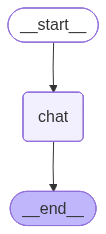

In [11]:
chatbot

In [18]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}
config1={"thread_id":"1"}

chatbot.invoke(initial_state,config1)['messages'][-1].content

[{'type': 'text',
  'text': 'The capital of India is **New Delhi**.',
  'extras': {'signature': 'ErMBCrABAb4+9vvQw+D53My6yIW5ha/zVcCSPegt6jBa0NUyJKLbt0QkXctphuz6jb8rxFL5EM5owAB3k9ZEv2VfzmgBGdyb9voDeJ4QLqYonlKPi7AOHBt1qcpt01u93dTnrR3LSsdLO2oJeriBFJkxXeqD8NWefqOQvuQpx6Lmerk/UfITJQoqzeDTJVhItdOd4Hw6YQFHT0xArF+Tf8zN0N3UdLSFMfwdFUpKkO+1UC/JYOI='}}]

In [31]:
thread_id="1"
while True:
    user_message=input('👦')
    if user_message.strip().lower() in ["exit","quit","bye"]:
        break
    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},{"configurable":{"thread_id":thread_id}})
    print('🖥️:',response['messages'][-1].content[0]["text"])

👦 Hello


ChatGoogleGenerativeAIError: Error calling model 'gemini-flash-latest' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 9.296575978s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT